In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

In [11]:
def create_pipeline(numeric_features, categorical_features, model, scaler='standard', imputer_strategy='mean'):
    
    if scaler == 'standard':
        scaler_obj = StandardScaler()
    else:
        scaler_obj = MinMaxScaler()
        
    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy=imputer_strategy)),
        ('scaler', scaler_obj)
    ])

    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features),
            ('cat', categorical_transformer, categorical_features)
        ])

    pipe = Pipeline(steps=[('preprocessor', preprocessor),
                           ('model', model)])
    return pipe

def run_multiple_splits(X, y, configurations, n_splits=10, is_classification=True):
    results = {name: [] for name in configurations.keys()}
    
    for i in range(n_splits):
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=i)
        
        for name, pipe in configurations.items():
            pipe.fit(X_train, y_train)
            preds = pipe.predict(X_test)
            
            if is_classification:
                score = accuracy_score(y_test, preds)
            else:
                score = np.sqrt(mean_squared_error(y_test, preds))
            
            results[name].append(score)
            
    return pd.DataFrame(results)

In [12]:
titanic = sns.load_dataset('titanic')
X_titanic = titanic.drop(columns=['survived', 'alive', 'deck', 'who', 'adult_male'])
y_titanic = titanic['survived']

num_features_tit = X_titanic.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features_tit = X_titanic.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

tips = sns.load_dataset('tips')
X_tips = tips.drop(columns=['tip'])
y_tips = tips['tip']

num_features_tip = X_tips.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features_tip = X_tips.select_dtypes(include=['category']).columns.tolist()

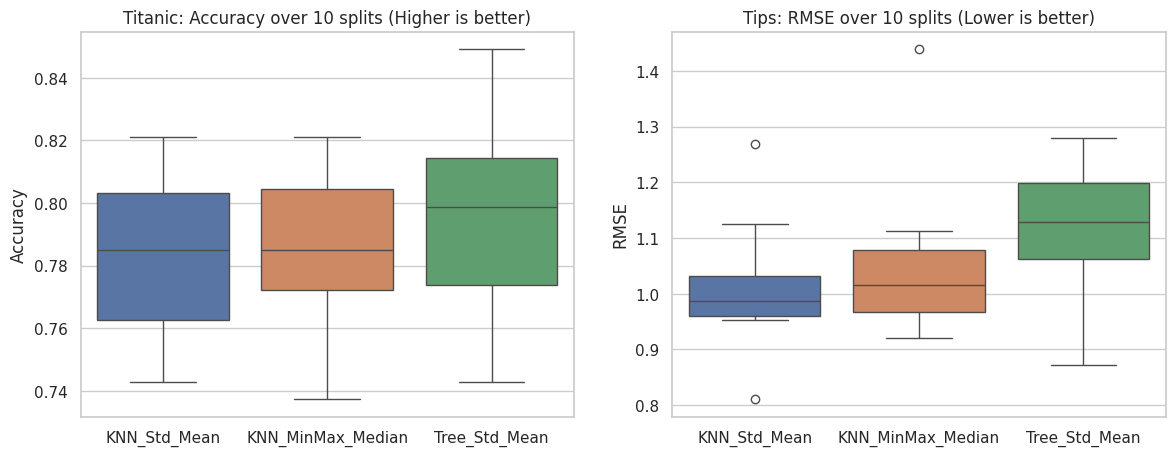

Best Titanic KNN params: {'model__n_neighbors': 5, 'model__weights': 'uniform'}
Best Tips KNN params: {'model__n_neighbors': 11, 'model__weights': 'distance'}


In [13]:
titanic_configs = {
    'KNN_Std_Mean': create_pipeline(num_features_tit, cat_features_tit, KNeighborsClassifier(), scaler='standard', imputer_strategy='mean'),
    'KNN_MinMax_Median': create_pipeline(num_features_tit, cat_features_tit, KNeighborsClassifier(), scaler='minmax', imputer_strategy='median'),
    'Tree_Std_Mean': create_pipeline(num_features_tit, cat_features_tit, DecisionTreeClassifier(max_depth=5), scaler='standard', imputer_strategy='mean')
}

tips_configs = {
    'KNN_Std_Mean': create_pipeline(num_features_tip, cat_features_tip, KNeighborsRegressor(), scaler='standard', imputer_strategy='mean'),
    'KNN_MinMax_Median': create_pipeline(num_features_tip, cat_features_tip, KNeighborsRegressor(), scaler='minmax', imputer_strategy='median'),
    'Tree_Std_Mean': create_pipeline(num_features_tip, cat_features_tip, DecisionTreeRegressor(max_depth=5), scaler='standard', imputer_strategy='mean')
}

titanic_results = run_multiple_splits(X_titanic, y_titanic, titanic_configs, n_splits=10, is_classification=True)
tips_results = run_multiple_splits(X_tips, y_tips, tips_configs, n_splits=10, is_classification=False)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=titanic_results, ax=ax[0])
ax[0].set_title('Titanic: Accuracy over 10 splits (Higher is better)')
ax[0].set_ylabel('Accuracy')

sns.boxplot(data=tips_results, ax=ax[1])
ax[1].set_title('Tips: RMSE over 10 splits (Lower is better)')
ax[1].set_ylabel('RMSE')
plt.show()

base_pipe_tit = create_pipeline(num_features_tit, cat_features_tit, KNeighborsClassifier())
param_grid_tit = {
    'model__n_neighbors': [3, 5, 7, 9, 11],
    'model__weights': ['uniform', 'distance']
}
gs_tit = GridSearchCV(base_pipe_tit, param_grid_tit, cv=5, scoring='accuracy')
gs_tit.fit(X_titanic, y_titanic)
print(f"Best Titanic KNN params: {gs_tit.best_params_}")

base_pipe_tip = create_pipeline(num_features_tip, cat_features_tip, KNeighborsRegressor())
param_grid_tip = {
    'model__n_neighbors': [3, 5, 7, 9, 11],
    'model__weights': ['uniform', 'distance']
}
gs_tip = GridSearchCV(base_pipe_tip, param_grid_tip, cv=5, scoring='neg_mean_squared_error')
gs_tip.fit(X_tips, y_tips)
print(f"Best Tips KNN params: {gs_tip.best_params_}")

              precision    recall  f1-score   support

           0       0.88      0.89      0.88       105
           1       0.84      0.82      0.83        74

    accuracy                           0.86       179
   macro avg       0.86      0.86      0.86       179
weighted avg       0.86      0.86      0.86       179



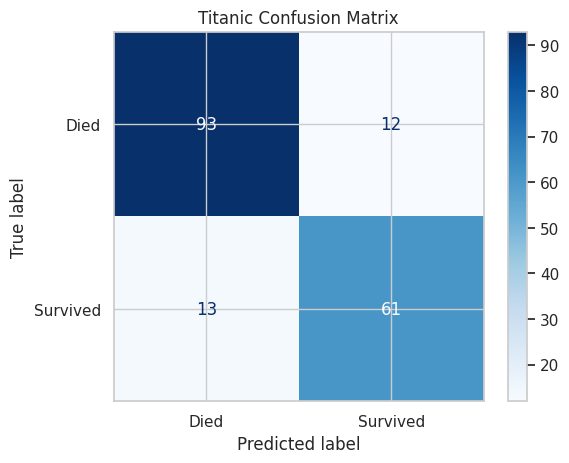

RMSE: 0.000
MAE: 0.000
R2 Score: 1.000


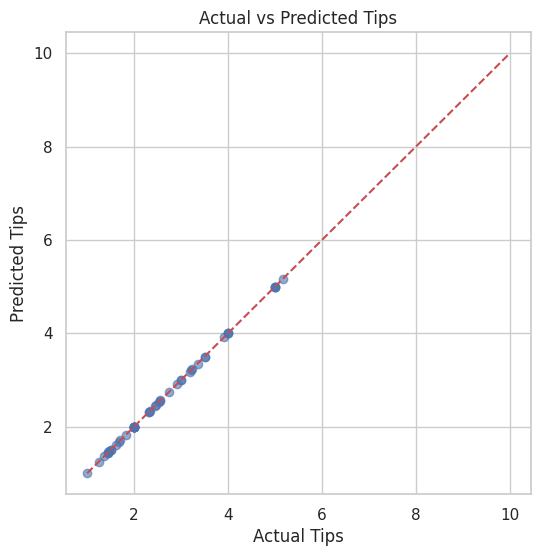

In [14]:
X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(X_titanic, y_titanic, test_size=0.2, random_state=42)
best_tit_model = gs_tit.best_estimator_
preds_t = best_tit_model.predict(X_test_t)

print(classification_report(y_test_t, preds_t))

cm = confusion_matrix(y_test_t, preds_t)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Died', 'Survived'])
disp.plot(cmap='Blues')
plt.title('Titanic Confusion Matrix')
plt.show()

X_train_tp, X_test_tp, y_train_tp, y_test_tp = train_test_split(X_tips, y_tips, test_size=0.2, random_state=42)
best_tip_model = gs_tip.best_estimator_
preds_tp = best_tip_model.predict(X_test_tp)

print(f"RMSE: {np.sqrt(mean_squared_error(y_test_tp, preds_tp)):.3f}")
print(f"MAE: {np.mean(np.abs(y_test_tp - preds_tp)):.3f}")
print(f"R2 Score: {r2_score(y_test_tp, preds_tp):.3f}")

plt.figure(figsize=(6, 6))
plt.scatter(y_test_tp, preds_tp, alpha=0.6)
plt.plot([y_tips.min(), y_tips.max()], [y_tips.min(), y_tips.max()], 'r--')
plt.xlabel('Actual Tips')
plt.ylabel('Predicted Tips')
plt.title('Actual vs Predicted Tips')
plt.show()

Мій опис результатів:
1. Titanic: Модель непогано передбачає загиблих (високий recall для класу 0), але трохи гірше справляється з тими, хто вижив. 
Як покращити: Можна спробувати Feature Engineering (наприклад, створити змінну "Розмір сім'ї" з parch та sibsp) або використати більш потужну модель типу Random Forest.
2. Tips: R2 score досить низький, а помилка (MAE) становить близько 0.7-0.8 доларів. Графік показує, що для високих чайових модель сильно помиляється (занижує їх).
Як покращити: Можливо, варто застосувати логарифмічне перетворення до цільової змінної, оскільки розподіл чайових зміщений.

<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB
None
              carat         depth         table         price             x  \
count  53940.000000  53940.000000  53940.000000  53940.000000  53940.000000   
mean       0.797940     61.749405     57.457184   3932.799722      5.731157   
std        0.474011      1.432621      2.234491   3989.439738      1.121761   
min        0.200000     43.000000     43.000000   

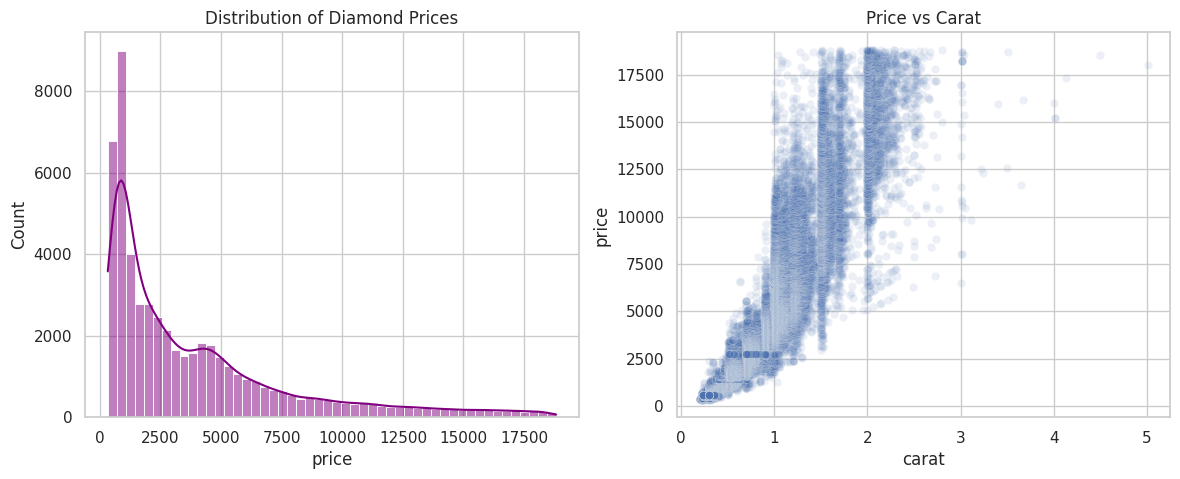

In [15]:
diamonds = sns.load_dataset('diamonds')

# 1. EDA
print(diamonds.info())
print(diamonds.describe())

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
# Розподіл ціни
sns.histplot(diamonds['price'], bins=50, kde=True, ax=ax[0], color='purple')
ax[0].set_title('Distribution of Diamond Prices')

# Залежність ціни від каратів
sns.scatterplot(data=diamonds, x='carat', y='price', alpha=0.1, ax=ax[1])
ax[1].set_title('Price vs Carat')
plt.show()



Інтерпретація EDA:
Ціна діамантів має сильно скошений вправо розподіл. Більшість діамантів коштують менше 5000.
На графіку Price vs Carat чітко видно нелінійну позитивну залежність — чим більше каратів, тим вища ціна.

In [16]:
X_dia = diamonds.drop(columns=['price'])
y_dia = diamonds['price']

num_features_dia = X_dia.select_dtypes(include=['float64']).columns.tolist()
cat_features_dia = X_dia.select_dtypes(include=['category', 'object']).columns.tolist()

dia_pipe = create_pipeline(num_features_dia, cat_features_dia, DecisionTreeRegressor(max_depth=10))

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(X_dia, y_dia, test_size=0.2, random_state=42)

dia_pipe.fit(X_train_d, y_train_d)
dia_preds = dia_pipe.predict(X_test_d)

print(f"RMSE: {np.sqrt(mean_squared_error(y_test_d, dia_preds)):.2f}")
print(f"R2 Score: {r2_score(y_test_d, dia_preds):.3f}")

RMSE: 722.20
R2 Score: 0.967


Опис результатів:
Дерево рішень з обмеженою глибиною показує дуже високий R2 (близько 0.96+). 
Це означає, що вага (карат) та розміри ідеально підходять для передбачення ціни.